# Atelier — Préparation de données tabulaires

---
# Partie 1 — Exploration des données

### 1) Chargement du dataset

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/smart_building_raw.csv")
print("Fichier chargé :", df.shape)

Fichier chargé : (507, 14)


### 2) Premières lignes

In [4]:
print(df.head())

   id_mesure                 date batiment      type_batiment zone  \
0       1174  2025-02-13 06:00:00       B8           Entrepôt    A   
1       1275  2025-03-10 12:00:00       B7             Bureau    D   
2       1493  2025-05-04 00:00:00       B5  Centre commercial    B   
3       1073  2025-01-19 00:00:00       B6         Université    D   
4       1454  2025-04-24 06:00:00       B7             Bureau    D   

   temperature  humidite     co2  occupation  consommation_kwh  \
0         23.0      40.0   851.0        26.0             138.4   
1         28.0      69.0   538.0         0.0             170.2   
2         19.5      52.3  1198.0        64.0             149.8   
3         20.0      58.4  1014.0        30.0             141.6   
4         26.8      70.5   628.0        42.0             228.3   

  mode_climatisation etat_systeme jour_semaine alerte  
0                Eco       Normal        Jeudi    Non  
1                Eco       Normal        Lundi    Non  
2             

### 3) Dernières lignes

In [5]:
print(df.tail())

     id_mesure                 date batiment      type_batiment zone  \
502       1107  2025-01-27 12:00:00       B2              École    C   
503       1271  2025-03-09 12:00:00       B3            Hôpital    B   
504       1349  2025-03-29 00:00:00       B5  Centre commercial    B   
505       1436  2025-04-19 18:00:00       B7             Bureau    C   
506       1103  2025-01-26 12:00:00       B2              École    D   

     temperature  humidite     co2  occupation  consommation_kwh  \
502         29.8      66.5   778.0        48.0             243.5   
503         21.1      66.3  3900.0        53.0             145.8   
504         21.6      61.9   959.0        33.0             100.2   
505         21.2      54.5  1066.0        38.0             150.9   
506          NaN      64.8   584.0        29.0             163.4   

    mode_climatisation etat_systeme jour_semaine alerte  
502             Normal       Normal        Lundi    Non  
503                Eco       Alerte     Di

### 4) Nombre d'observations

In [6]:
print("Nombre d'observations :", df.shape[0])

Nombre d'observations : 507


### 5) Nombre de variables

In [7]:
print("Nombre de variables :", df.shape[1])

Nombre de variables : 14


### 6) Identifier les variables numériques

In [8]:
variables_numeriques = df.select_dtypes(include="number").columns.tolist()
print("Variables numériques :", variables_numeriques)

Variables numériques : ['id_mesure', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']


### 7) Identifier les variables catégorielles

In [10]:
variables_categorielles = df.select_dtypes(include=["object", "str", "category"]).columns.tolist()
print("Variables catégorielles :", variables_categorielles)

Variables catégorielles : ['date', 'batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


### 8) Identifier les dates

In [23]:
n_dates_before = df["date"].shape[0]
df["date"] = pd.to_datetime(df["date"], errors="coerce")
n_dates_invalid = df["date"].isna().sum()

print(f"Nombre de dates invalides : {n_dates_invalid} sur {n_dates_before}")
print("Variables de dates :", df["date"])

Nombre de dates invalides : 5 sur 507
Variables de dates : 0     2025-02-13 06:00:00
1     2025-03-10 12:00:00
2     2025-05-04 00:00:00
3     2025-01-19 00:00:00
4     2025-04-24 06:00:00
              ...        
502   2025-01-27 12:00:00
503   2025-03-09 12:00:00
504   2025-03-29 00:00:00
505   2025-04-19 18:00:00
506   2025-01-26 12:00:00
Name: date, Length: 507, dtype: datetime64[us]


### 9) Variables identifiantes

In [28]:
identifiants = ["id_mesure"]
print("Variable(s) identifiant(s) :", identifiants)
print("Nombre de valeurs uniques dans id_mesure :", df["id_mesure"].nunique(), "sur", len(df))

Variable(s) identifiant(s) : ['id_mesure']
Nombre de valeurs uniques dans id_mesure : 500 sur 507


### 10) Déterminer les statistiques : moyenne, médiane, minimum, maximum, écart-type et quartiles.

In [29]:
stats_numeriques = df[variables_numeriques].describe().T
stats_numeriques["median"] = df[variables_numeriques].median()
stats_numeriques

,count,mean,std,min,25%,50%,75%,max,median
id_mesure,507.0,1251.114398,144.782769,1001.0,1125.500,1252.00,1376.500,1500.0,1252.00
temperature,495.0,24.154141,7.418465,-30.0,21.600,24.00,26.000,96.0,24.00
humidite,496.0,57.864113,16.026336,-12.0,49.275,57.55,65.750,160.0,57.55
co2,500.0,844.150000,582.181386,89.0,623.750,787.50,952.000,6000.0,787.50
occupation,501.0,44.850299,24.949139,-20.0,27.000,46.00,61.000,116.0,46.00
consommation_kwh,502.0,169.069323,53.164294,-100.0,136.875,169.80,202.975,336.2,169.80


### 11)Y a-t-il des variables potentiellement problématiques ?

On croise un premier coup d'œil sur les valeurs manquantes, les valeurs extrêmes (min/max issus de la question précédente) et le nombre de catégories par variable catégorielle pour repérer les variables suspectes.

In [33]:
print("=== Valeurs manquantes par colonne ===")
print(df.isna().sum())

print("\n=== Étendue (min/max) des variables numériques ===")
print(df[variables_numeriques].agg(["min", "max"]).T)


=== Valeurs manquantes par colonne ===
id_mesure              0
date                   0
batiment               0
type_batiment          4
zone                   0
temperature           12
humidite              11
co2                    7
occupation             6
consommation_kwh       5
mode_climatisation     5
etat_systeme           0
jour_semaine           5
alerte                 0
dtype: int64

=== Étendue (min/max) des variables numériques ===
                     min     max
id_mesure         1001.0  1500.0
temperature        -30.0    96.0
humidite           -12.0   160.0
co2                 89.0  6000.0
occupation         -20.0   116.0
consommation_kwh  -100.0   336.2


### 12)Détecter et corriger les données incohérentes

In [43]:
df_clean = df.copy()

# a) humidité < 0
mask_humidite_neg = df_clean["humidite"] < 0
print("a) humidité < 0 :", mask_humidite_neg.sum(), "valeurs")

# b) humidité > 100
mask_humidite_sup = df_clean["humidite"] > 100
print("b) humidité > 100 :", mask_humidite_sup.sum(), "valeurs")

# c) température extrêmement élevée (ou extrêmement basse, tout aussi impossible pour un bâtiment)
# on définit une plage physiquement plausible pour une température intérieure/extérieure de bâtiment
mask_temp_extreme = (df_clean["temperature"] > 45) | (df_clean["temperature"] < -10)
print("c) température extrême (hors [-10, 45] °C) :", mask_temp_extreme.sum(), "valeurs")

# d) valeurs négatives -> occupation ne peut pas être négative (nombre de personnes)
mask_occupation_neg = df_clean["occupation"] < 0
print("d) occupation négative :", mask_occupation_neg.sum(), "valeurs")

# e) consommation négative -> une consommation énergétique ne peut pas être négative
mask_conso_neg = df_clean["consommation_kwh"] < 0
print("e) consommation négative :", mask_conso_neg.sum(), "valeurs")

a) humidité < 0 : 3 valeurs
b) humidité > 100 : 7 valeurs
c) température extrême (hors [-10, 45] °C) : 6 valeurs
d) occupation négative : 5 valeurs
e) consommation négative : 4 valeurs


##### f) Ces valeurs sont manifestement erronées et on ne peut pas retrouver leur vraie valeur

In [45]:
#on les transforme en valeurs manquantes (NaN)
df_clean.loc[mask_humidite_neg | mask_humidite_sup, "humidite"] = np.nan
df_clean.loc[mask_temp_extreme, "temperature"] = np.nan
df_clean.loc[mask_occupation_neg, "occupation"] = np.nan
df_clean.loc[mask_conso_neg, "consommation_kwh"] = np.nan

print("f) Valeurs incohérentes transformées en NaN.")
print(df_clean[["humidite", "temperature", "occupation", "consommation_kwh"]].isna().sum())

f) Valeurs incohérentes transformées en NaN.
humidite            21
temperature         18
occupation          11
consommation_kwh     9
dtype: int64


##### g) Recherche de catégories mal orthographiées 

In [48]:
for c in ["type_batiment", "mode_climatisation"]:
    print(f"--- {c} ---")
    print(sorted(df_clean[c].dropna().unique().tolist()))
    print()

--- type_batiment ---
[' Bureau ', ' UNIVERSITÉ', 'BUREAU', 'Bureau', 'Bureu', 'Centre commercial', 'Entrepôt', 'Hôpital', 'Université', 'bureau', 'centre commercial', 'ecole', 'entrepot', 'hôpital ', 'ÉCOLE', 'École']

--- mode_climatisation ---
['BOOST', 'Boost', 'Eco', 'Normal', 'Normal ', 'normal', 'normale']



##### h) Normalisation : suppression des espaces puis uniformisation de la casse,puis correction des fautes de frappe restantes vers une catégorie canonique

In [ ]:
import os

# Étape 1 : strip + lower pour toutes les colonnes textuelles catégorielles
# (on reste en dtype "object" : le nettoyage pandas .str gère nativement les NaN existants
#  sans les transformer en pd.NA, ce qui évite des soucis de compatibilité avec scikit-learn)
for c in ["batiment", "type_batiment", "zone", "mode_climatisation", "etat_systeme",
          "jour_semaine", "alerte"]:
    df_clean[c] = df_clean[c].str.strip().str.lower()

# Étape 2 : dictionnaires de correction (fautes de frappe -> catégorie canonique)
mapping_type_batiment = {
    "entrepot": "Entrepôt", "entrepôt": "Entrepôt",
    "bureau": "Bureau", "bureu": "Bureau",
    "centre commercial": "Centre commercial",
    "université": "Université", "universite": "Université",
    "hôpital": "Hôpital", "hopital": "Hôpital",
    "ecole": "École", "école": "École",
}
mapping_mode_clim = {
    "eco": "Eco",
    "normal": "Normal", "normale": "Normal",
    "boost": "Boost",
}

df_clean["type_batiment"] = df_clean["type_batiment"].map(mapping_type_batiment)
df_clean["mode_climatisation"] = df_clean["mode_climatisation"].map(mapping_mode_clim)

# Les autres colonnes catégorielles sont remises en casse "Titre" pour la lisibilité
df_clean["etat_systeme"] = df_clean["etat_systeme"].str.capitalize()
df_clean["jour_semaine"] = df_clean["jour_semaine"].str.capitalize()
df_clean["alerte"] = df_clean["alerte"].str.capitalize()

print("Catégories après normalisation :")
for c in ["batiment", "type_batiment", "zone", "mode_climatisation", "etat_systeme",
          "jour_semaine", "alerte"]:
    print(f"{c} : {sorted(df_clean[c].dropna().unique().tolist())}")

df_clean.to_csv(os.path.join("../exports/", "01_incoherences_corrigees.csv"), index=False)
print("\nExport intermédiaire -> exports/01_incoherences_corrigees.csv")

Catégories après normalisation :
batiment : ['b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8']
type_batiment : ['Bureau', 'Centre commercial', 'Entrepôt', 'Hôpital', 'Université', 'École']
zone : ['a', 'b', 'c', 'd']
mode_climatisation : ['Boost', 'Eco', 'Normal']
etat_systeme : ['Alerte', 'Normal', 'Panne']
jour_semaine : ['Dimanche', 'Jeudi', 'Lundi', 'Mardi', 'Mercredi', 'Samedi', 'Vendredi']
alerte : ['Non', 'Oui']

Export intermédiaire -> exports/01_incoherences_corrigees.csv


#### 13) Pour les valeurs manquantes
##### a) Calculer le nombre et le pourcentage de valeurs manquantes par colonne

In [52]:
# a) Nombre et pourcentage de valeurs manquantes par colonne
nb_manquants = df_clean.isna().sum()
pct_manquants = (df_clean.isna().mean() * 100).round(2)
missing_report = pd.DataFrame({"nb_manquants": nb_manquants, "pourcentage_manquants": pct_manquants})
missing_report = missing_report[missing_report["nb_manquants"] > 0].sort_values(
    "pourcentage_manquants", ascending=False)
missing_report

,nb_manquants,pourcentage_manquants
humidite,21,4.14
temperature,18,3.55
occupation,11,2.17
consommation_kwh,9,1.78
co2,7,1.38
mode_climatisation,5,0.99
jour_semaine,5,0.99
type_batiment,4,0.79


##### b) Quelle variable possède le plus de valeurs manquantes ?

In [53]:
variable_plus_manquante = missing_report.index[0]
print(f"b) Variable avec le plus de valeurs manquantes : '{variable_plus_manquante}' "
      f"({missing_report.iloc[0]['pourcentage_manquants']} %)")

b) Variable avec le plus de valeurs manquantes : 'humidite' (4.14 %)


#### c) Quelle stratégie utiliser pour les valeurs manquantes ?

Une imputation ciblée par type de variable : médiane pour les variables numériques (robuste aux valeurs extrêmes déjà repérées en Question 12), mode (valeur la plus fréquente) pour les variables catégorielles. 

##### d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ?

Non, ou en tout cas pas systématiquement. Le pourcentage de valeurs manquantes reste
faible par colonne, mais un dropna() global supprimerait toutes les lignes ayant AU MOINS
une valeur manquante sur N'IMPORTE QUELLE colonne, ce qui ferait perdre une part importante
et potentiellement biaisée des observations (voir calcul ci-dessous).


In [54]:
lignes_avant = len(df_clean)
lignes_sans_na = len(df_clean.dropna())
print(f"Lignes totales : {lignes_avant}")
print(f"Lignes restantes après dropna() global : {lignes_sans_na}")
print(f"Lignes perdues : {lignes_avant - lignes_sans_na} ")

Lignes totales : 507
Lignes restantes après dropna() global : 434
Lignes perdues : 73 


##### e) Dans quels cas utiliser la moyenne ?

Quand la variable suit une distribution à peu près symétrique et sans valeurs aberrantes
marquées : la moyenne est alors représentative de la tendance centrale.

##### f) Quand préférer la médiane ?

Quand la distribution est asymétrique ou contient des valeurs extrêmes (outliers) :
la médiane, contrairement à la moyenne, n'est pas sensible à ces valeurs extrêmes.

##### g) Comment traiter une variable catégorielle ?

En imputant par le mode (la catégorie la plus fréquente), ou en créant une catégorie explicite 'Inconnu'/'Manquant' si l'absence de valeur peut avoir un sens en soi.

#### 14) Détecter et traiter les doublons

##### a) Identifier les doublons

In [56]:
#Identifier les doublons (lignes strictement identiques sur toutes les colonnes)
duplicated_mask = df_clean.duplicated(keep=False)
print(f"Nombre de lignes impliquées dans un doublon : {duplicated_mask.sum()}")

Nombre de lignes impliquées dans un doublon : 14


##### b) Afficher les doublons

In [57]:
doublons = df_clean[duplicated_mask].sort_values(list(df_clean.columns))
doublons

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
117,1026,2025-01-07 06:00:00,b6,Bureau,a,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
192,1026,2025-01-07 06:00:00,b6,Bureau,a,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
9,1118,2025-01-30 06:00:00,b1,Bureau,a,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
123,1118,2025-01-30 06:00:00,b1,Bureau,a,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
23,1264,2025-03-07 18:00:00,b1,Bureau,b,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
434,1264,2025-03-07 18:00:00,b1,Bureau,b,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
455,1320,2025-03-21 18:00:00,b7,Bureau,b,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
464,1320,2025-03-21 18:00:00,b7,Bureau,b,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
238,1402,2025-04-11 06:00:00,b2,École,a,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non
418,1402,2025-04-11 06:00:00,b2,École,a,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non


##### c) Sont-ils réellement identiques ? 

In [59]:
#on vérifie via duplicated() strict (toutes colonnes)
nb_doublons_stricts = df_clean.duplicated(keep="first").sum()
print(f"Nombre de doublons stricts (identiques sur toutes les colonnes, hors 1ère occurrence) : "
      f"{nb_doublons_stricts}")

Nombre de doublons stricts (identiques sur toutes les colonnes, hors 1ère occurrence) : 7


Ce sont bien de vrais doublons (même id_mesure, même date, mêmes mesures),
on peut les supprimer sans risque de perte d'information.

##### d) Supprimer les doublons réellement identifiés 

In [68]:
# Supprimer les doublons réellement identifiés (on garde la première occurrence)
lignes_avant_dedup = len(df)
df_clean = df.drop_duplicates(keep="first").reset_index(drop=True)
lignes_apres_dedup = len(df_clean)
print(f"   Lignes avant déduplication : {lignes_avant_dedup}")
print(f"   Lignes après déduplication  : {lignes_apres_dedup}")
print(f"   Doublons supprimés          : {lignes_avant_dedup - lignes_apres_dedup}")

   Lignes avant déduplication : 507
   Lignes après déduplication  : 500
   Doublons supprimés          : 7


##### e) Vérifier la suppression

In [70]:
import os
print("e) Nombre de doublons restants :", df_clean.duplicated().sum())
df_clean.to_csv(os.path.join("../exports/", "02_sans_doublons.csv"), index=False)
print("Export intermédiaire -> exports/02_sans_doublons.csv")

e) Nombre de doublons restants : 0
Export intermédiaire -> exports/02_sans_doublons.csv


#### 15) Distributions, dispersion et valeurs extrêmes (température, humidité, CO₂, consommation)

##### a) la distribution (histogramme + asymétrie), b) la dispersion (boxplot), c) les valeurs extrêmes

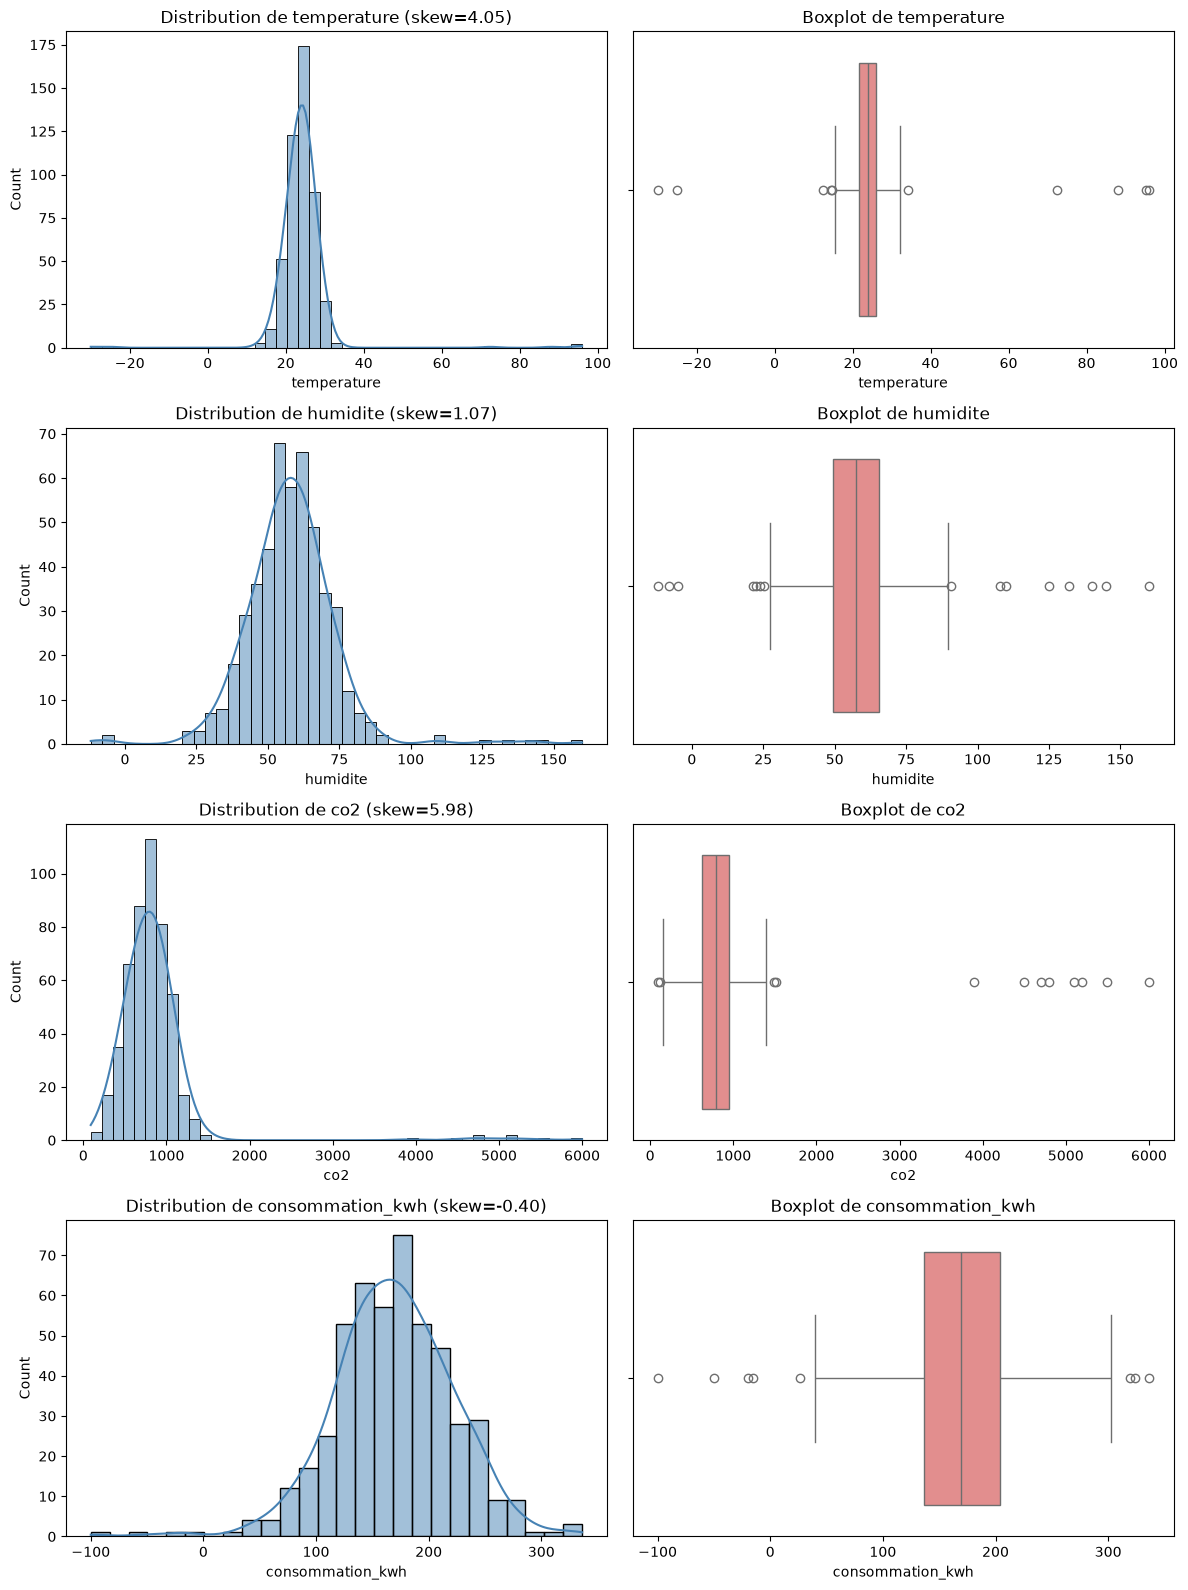

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_a_visualiser = ["temperature", "humidite", "co2", "consommation_kwh"]

fig, axes = plt.subplots(len(cols_a_visualiser), 2, figsize=(12, 4 * len(cols_a_visualiser)))
for i, col in enumerate(cols_a_visualiser):
    sns.histplot(df_clean[col].dropna(), kde=True, ax=axes[i, 0], color="steelblue")
    axes[i, 0].set_title(f"Distribution de {col} (skew={df_clean[col].skew():.2f})")
    sns.boxplot(x=df_clean[col], ax=axes[i, 1], color="lightcoral")
    axes[i, 1].set_title(f"Boxplot de {col}")



plt.tight_layout()
plt.show()

##### d) Détection chiffrée des valeurs aberrantes potentielles via la règle de l'IQR (1.5 x IQR)

In [90]:

def bornes_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in cols_a_visualiser:
    borne_inf, borne_sup = bornes_iqr(df_clean[col].dropna())
    nb_outliers = ((df_clean[col] < borne_inf) | (df_clean[col] > borne_sup)).sum()
    print(f"{col} : bornes IQR = [{borne_inf:.1f} ; {borne_sup:.1f}] "
          f"-> {nb_outliers} valeurs potentiellement aberrantes "
          f"(asymétrie : {'oui' if abs(df_clean[col].skew()) > 0.5 else 'non'})")

temperature : bornes IQR = [15.0 ; 32.6] -> 10 valeurs potentiellement aberrantes (asymétrie : oui)
humidite : bornes IQR = [25.3 ; 89.8] -> 15 valeurs potentiellement aberrantes (asymétrie : oui)
co2 : bornes IQR = [132.0 ; 1444.0] -> 12 valeurs potentiellement aberrantes (asymétrie : oui)
consommation_kwh : bornes IQR = [35.1 ; 305.1] -> 8 valeurs potentiellement aberrantes (asymétrie : non)
